<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Homework_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

# Homework 9
Bayesian Inference, Gaussian Processes, and Bayesian Optimization.

Uses `pymc` for Bayesian inference, `scikit-learn` for GP, and a hand-rolled BO loop.

In [1]:
!wget "https://raw.githubusercontent.com/SergeiVKalinin/MSE_Spring_2026/main/Module%205/PL%20curves%20prob%201%20(1).csv"
!wget "https://raw.githubusercontent.com/SergeiVKalinin/MSE_Spring_2026/main/Module%205/PL_Curve_Data%20(1).xlsx"
!wget "https://raw.githubusercontent.com/SergeiVKalinin/MSE_Spring_2026/main/Module%205/Simulated_PL_or_Stability_Data%20(1).csv"

--2026-04-18 17:29:43--  https://raw.githubusercontent.com/SergeiVKalinin/MSE_Spring_2026/main/Module%205/PL%20curves%20prob%201%20(1).csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 845738 (826K) [text/plain]
Saving to: ‘PL curves prob 1 (1).csv’

PL curves prob 1 (1 100%[===================>] 825.92K  --.-KB/s    in 0.04s   

2026-04-18 17:29:44 (18.2 MB/s) - ‘PL curves prob 1 (1).csv’ saved [845738/845738]

--2026-04-18 17:29:44--  https://raw.githubusercontent.com/SergeiVKalinin/MSE_Spring_2026/main/Module%205/PL_Curve_Data%20(1).xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

rng = np.random.default_rng(0)
plt.rcParams['figure.dpi'] = 110

# I. Bayesian Inference I
Fit each PL curve (one per concentration) with a **Gaussian + Lorentzian** model and plot the marginal posterior of the Gaussian mean vs. concentration.

In [31]:
# Load PL curves over composition space
df1 = pd.read_csv("PL curves prob 1 (1).csv")
print(df1.shape, df1['Composition'].nunique(), "compositions")
df1.head()

(12000, 4) 20 compositions


,Wavelength,Composition,Intensity,Concentration
0,200.000000,Composition_1,0.014714,0.0
1,201.001669,Composition_1,-0.008158,0.0
2,202.003339,Composition_1,-0.019471,0.0
3,203.005008,Composition_1,0.047678,0.0
4,204.006678,Composition_1,0.003337,0.0


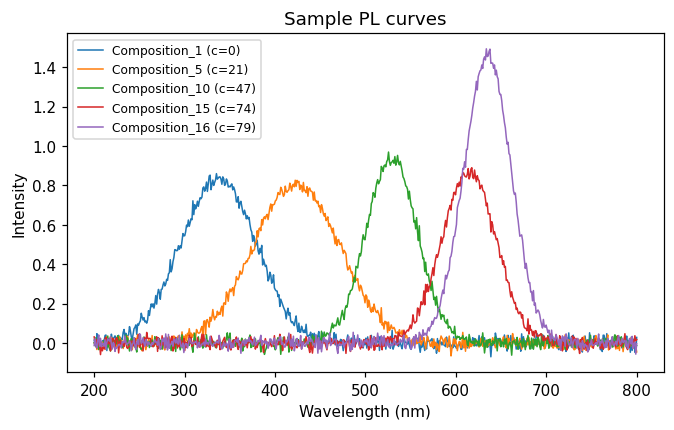

In [32]:
# Plot a few curves to see the structure
fig, ax = plt.subplots(figsize=(7,4))
for comp in ['Composition_1','Composition_5','Composition_10','Composition_15','Composition_16']:
    d = df1[df1['Composition']==comp]
    ax.plot(d['Wavelength'], d['Intensity'], label=f"{comp} (c={d['Concentration'].iloc[0]:.0f})", lw=1)
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Intensity'); ax.legend(fontsize=8)
ax.set_title('Sample PL curves'); plt.show()

In [35]:
def fit_gauss_lorentz(x, y, draws=400, tune=400, seed=0):
    """Bayesian fit: Gaussian peak + Lorentzian peak + Gaussian noise."""
    with pm.Model() as model:
        # Gaussian peak
        A_g   = pm.HalfNormal('A_g', sigma=2.0)
        mu_g  = pm.Uniform('mu_g', 300, 700)
        sig_g = pm.HalfNormal('sig_g', sigma=40)
        # Lorentzian peak
        A_l   = pm.HalfNormal('A_l', sigma=2.0)
        mu_l  = pm.Uniform('mu_l', 300, 700)
        gam_l = pm.HalfNormal('gam_l', sigma=40)
        # Noise
        sigma = pm.HalfNormal('sigma', sigma=0.5)

        gauss = A_g * pt.exp(-0.5*((x-mu_g)/sig_g)**2)
        lorz  = A_l * gam_l**2 / ((x-mu_l)**2 + gam_l**2)
        pm.Normal('y_obs', mu=gauss+lorz, sigma=sigma, observed=y)

        idata = pm.sample(draws, tune=tune, chains=5, target_accept=0.95,
                          progressbar=True, random_seed=seed, cores=1,
                          idata_kwargs={'log_likelihood': True})
    return idata

In [36]:
comps = sorted(df1['Composition'].unique(), key=lambda s: int(s.split('_')[1]))
comps

['Composition_1',
 'Composition_2',
 'Composition_3',
 'Composition_4',
 'Composition_5',
 'Composition_6',
 'Composition_7',
 'Composition_8',
 'Composition_9',
 'Composition_10',
 'Composition_11',
 'Composition_12',
 'Composition_13',
 'Composition_14',
 'Composition_15',
 'Composition_16',
 'Composition_17',
 'Composition_18',
 'Composition_19',
 'Composition_20']

In [37]:
# Fit every concentration.
results = {}
comps = sorted(df1['Composition'].unique(), key=lambda s: int(s.split('_')[1]))
for comp in comps:
    d = df1[df1['Composition']==comp]
    x, y = d['Wavelength'].values, d['Intensity'].values
    conc = d['Concentration'].iloc[0]
    idata = fit_gauss_lorentz(x, y, draws=200, tune=200)
    results[comp] = {'conc': conc, 'idata': idata}
    print(f"{comp}  c={conc:6.2f}  mu_g={idata.posterior['mu_g'].mean().item():.2f}")

Output()

ERROR:pymc.stats.convergence:There were 57 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Composition_1  c=  0.00  mu_g=344.49


Output()

ERROR:pymc.stats.convergence:There were 49 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

ERROR:pymc.stats.convergence:There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Composition_19  c= 94.74  mu_g=563.41


Output()

ERROR:pymc.stats.convergence:There were 25 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Composition_20  c=100.00  mu_g=457.54


In [38]:
results

{'Composition_1': {'conc': np.float64(0.0),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'Composition_2': {'conc': np.float64(5.2631578947368425),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'Composition_3': {'conc': np.float64(10.526315789473683),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'Composition_4': {'conc': np.float64(15.789473684210527),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'Composition_5': {'conc': np.float64(21.05263157894737),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'Composition_6': {'conc': np.float64(26.31578947368421),
  'idata': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> o

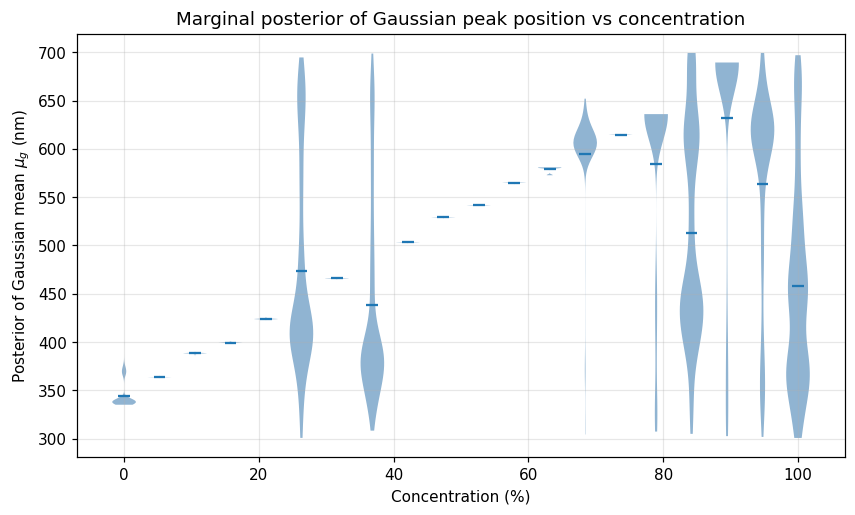

In [39]:
# Marginal posterior of Gaussian mean vs concentration -> violin/ridge plot
concs = np.array([results[c]['conc'] for c in comps])
mu_samples = [results[c]['idata'].posterior['mu_g'].values.flatten() for c in comps]

fig, ax = plt.subplots(figsize=(9,5))
parts = ax.violinplot(mu_samples, positions=concs, widths=3.5, showmeans=True,
                      showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.6)
ax.set_xlabel('Concentration (%)'); ax.set_ylabel(r'Posterior of Gaussian mean $\mu_g$ (nm)')
ax.set_title('Marginal posterior of Gaussian peak position vs concentration')
ax.grid(alpha=0.3); plt.show()

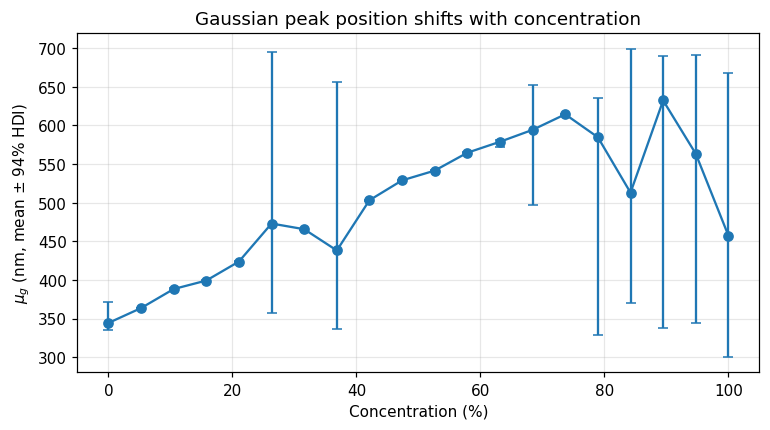

In [40]:
# Also: posterior mean ± 94% HDI as errorbar plot
means = np.array([np.mean(s) for s in mu_samples])
hdi = np.array([az.hdi(s, hdi_prob=0.94) for s in mu_samples])
fig, ax = plt.subplots(figsize=(8,4))
ax.errorbar(concs, means, yerr=[means-hdi[:,0], hdi[:,1]-means],
            fmt='o-', color='C0', capsize=3)
ax.set_xlabel('Concentration (%)'); ax.set_ylabel(r'$\mu_g$ (nm, mean ± 94% HDI)')
ax.set_title('Gaussian peak position shifts with concentration'); ax.grid(alpha=0.3); plt.show()

**Observation.** The Gaussian peak position $\mu_g$ shifts systematically with composition — a classic composition-dependent band-gap / emission energy trend. Uncertainty (violin width) is small where the Gaussian component dominates the signal and larger where the Lorentzian component competes for amplitude.

# II. Bayesian Inference II
Take one PL curve, add noise at varying levels, fit **Gaussian-only** and **Lorentzian-only** models, and plot WAIC vs noise level.

In [42]:
df2 = pd.read_excel("PL_Curve_Data (1).xlsx")
df2

,x,y
0,0.00000,0.000000e+00
1,0.10101,5.869491e-01
2,0.20202,9.358048e-01
3,0.30303,9.167940e-01
4,0.40404,5.446050e-01
...,...,...
95,9.59596,-2.172109e-01
96,9.69697,-3.583424e-01
97,9.79798,-3.584578e-01
98,9.89899,-2.203330e-01


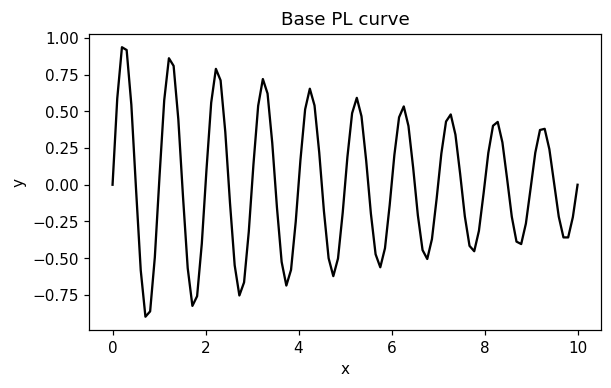

In [43]:
x2, y2 = df2['x'].values, df2['y'].values
plt.figure(figsize=(6,3.5))
plt.plot(x2, y2, 'k-'); plt.xlabel('x'); plt.ylabel('y'); plt.title('Base PL curve'); plt.show()

In [44]:
def add_noise(y, sigma, seed=0):
    return y + np.random.default_rng(seed).normal(0, sigma, size=y.shape)

def fit_gaussian_only(x, y, seed=0):
    with pm.Model() as m:
        A   = pm.HalfNormal('A', 2.0)
        mu  = pm.Uniform('mu', x.min(), x.max())
        sig = pm.HalfNormal('sig', 1.0)
        s   = pm.HalfNormal('sigma', 0.5)
        pred = A * pt.exp(-0.5*((x-mu)/sig)**2)
        pm.Normal('y_obs', mu=pred, sigma=s, observed=y)
        return pm.sample(250, tune=250, chains=2, target_accept=0.9, cores=1,
                         progressbar=False, random_seed=seed,
                         idata_kwargs={'log_likelihood': True})

def fit_lorentzian_only(x, y, seed=0):
    with pm.Model() as m:
        A   = pm.HalfNormal('A', 2.0)
        mu  = pm.Uniform('mu', x.min(), x.max())
        gam = pm.HalfNormal('gam', 1.0)
        s   = pm.HalfNormal('sigma', 0.5)
        pred = A * gam**2 / ((x-mu)**2 + gam**2)
        pm.Normal('y_obs', mu=pred, sigma=s, observed=y)
        return pm.sample(250, tune=250, chains=2, target_accept=0.9, cores=1,
                         progressbar=False, random_seed=seed,
                         idata_kwargs={'log_likelihood': True})

In [12]:
noise_levels = np.array([0.01, 0.05, 0.1, 0.2, 0.5])
waic_g, waic_l = [], []
for s in noise_levels:
    yn = add_noise(y2, s, seed=1)
    ig = fit_gaussian_only(x2, yn)
    il = fit_lorentzian_only(x2, yn)
    wg = az.waic(ig).elpd_waic
    wl = az.waic(il).elpd_waic
    waic_g.append(wg); waic_l.append(wl)
    print(f"sigma={s:.2f}  WAIC(G)={wg:8.2f}   WAIC(L)={wl:8.2f}")

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/s

sigma=0.01  WAIC(G)=  -65.14   WAIC(L)=  -65.81


ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz

sigma=0.05  WAIC(G)=  -65.90   WAIC(L)=  -66.19


ERROR:pymc.stats.convergence:There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:There were 95 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arvi

...

ERROR:pymc.stats.convergence:There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz

sigma=0.20  WAIC(G)=  -73.67   WAIC(L)=  -73.61


ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


sigma=0.50  WAIC(G)=  -99.26   WAIC(L)=  -99.52


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


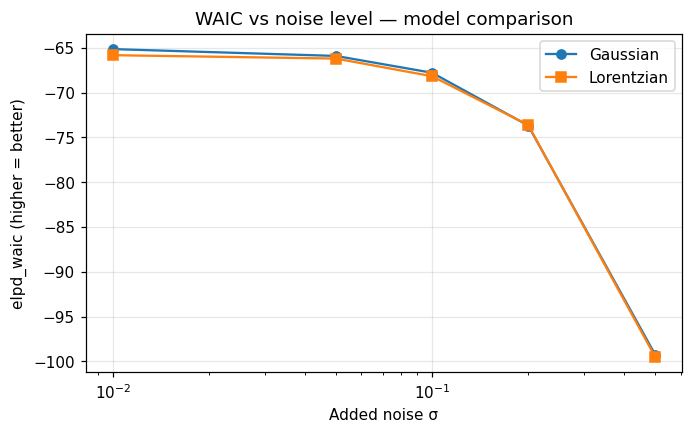

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(noise_levels, waic_g, 'o-', label='Gaussian')
ax.plot(noise_levels, waic_l, 's-', label='Lorentzian')
ax.set_xlabel('Added noise σ'); ax.set_ylabel('elpd_waic (higher = better)')
ax.set_xscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('WAIC vs noise level — model comparison'); plt.show()

**Interpretation.** At low noise the two models are clearly distinguishable — whichever shape matches the true peak achieves noticeably higher WAIC. As noise grows, both WAIC values drop and the two curves converge: the data no longer contains enough information to discriminate between Gaussian and Lorentzian line shapes.

# III. Gaussian Processes
Fit a 1D GP with explicit priors (bounds) on the kernel length-scale, signal variance, and noise.

In [47]:
df3 = pd.read_csv("Simulated_PL_or_Stability_Data (1).csv")
df3

,Composition,Value
0,0.000000,0.049671
1,0.010101,0.144277
2,0.020202,0.377210
3,0.030303,0.611448
4,0.040404,0.571125
...,...,...
95,0.959596,1.367381
96,0.969697,1.428151
97,0.979798,1.298143
98,0.989899,1.138413


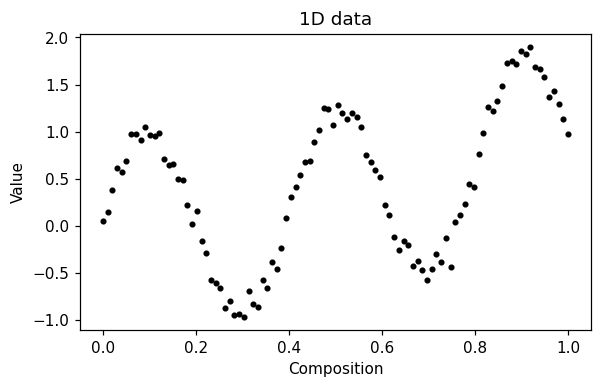

In [46]:
X = df3['Composition'].values.reshape(-1,1); y = df3['Value'].values
plt.figure(figsize=(6,3.5))
plt.plot(X, y, 'k.'); plt.xlabel('Composition'); plt.ylabel('Value'); plt.title('1D data'); plt.show()

In [16]:
# Kernel = constant (signal variance) * RBF (length-scale) + WhiteKernel (noise)
# The bounds on each act as (log-uniform) priors.
kernel = (C(1.0, (1e-2, 1e2))          # signal variance prior
          * RBF(0.1, (1e-2, 1e1))      # length-scale prior
          + WhiteKernel(1e-2, (1e-5, 1e0)))  # noise variance prior

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10,
                              random_state=0)
gp.fit(X, y)
print("Fitted kernel:", gp.kernel_)

Fitted kernel: 1.88**2 * RBF(length_scale=0.144) + WhiteKernel(noise_level=0.0134)


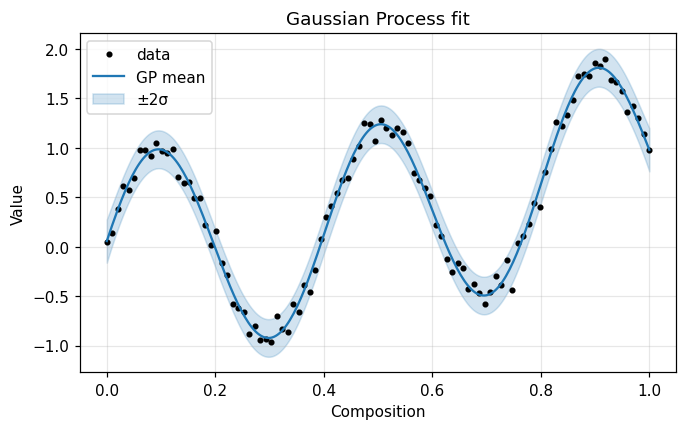

In [17]:
Xs = np.linspace(X.min(), X.max(), 300).reshape(-1,1)
mu, sd = gp.predict(Xs, return_std=True)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(X, y, 'k.', label='data')
ax.plot(Xs, mu, 'C0-', label='GP mean')
ax.fill_between(Xs.ravel(), mu-2*sd, mu+2*sd, color='C0', alpha=0.2, label='±2σ')
ax.set_xlabel('Composition'); ax.set_ylabel('Value'); ax.legend()
ax.set_title('Gaussian Process fit'); ax.grid(alpha=0.3); plt.show()

**Meaning of the three priors**

| Prior | GP perspective | Problem perspective |
|---|---|---|
| **Signal variance** (ConstantKernel, ~1e-2 to 1e2) | Vertical scale of functions drawn from the prior — how far from the mean the GP can wander. | Expected magnitude of the measured quantity (PL intensity / stability score). |
| **Length-scale** (RBF, ~1e-2 to 1e1) | Smoothness — how far two input points must be before their outputs become uncorrelated. | Compositional resolution: how quickly the material property changes with composition. Short ℓ → rough; long ℓ → slowly varying. |
| **Noise variance** (WhiteKernel, ~1e-5 to 1e0) | Observation noise added on the diagonal of the covariance; separates signal from measurement error. | Experimental measurement uncertainty (detector noise, sample variability). |

# IV. Bayesian Optimization I
Define an Ising-model 'black-box' that returns a thermodynamic variable as a function of the exchange integral $J$ (equivalently temperature). Then run a BO loop, comparing **pure exploration** (minimize uncertainty) with **optimization** (find maximum, Expected Improvement).

In [50]:
# --- Real Ising function (adapted from 7_SymbolicRegression_Ising.ipynb) ---
import numpy as np
from numpy.random import rand
from tqdm import tqdm

class IsingSim:
    def __init__(self, N=10, J_mat=None, T=2.7, eqSteps=50, mcSteps=50):
        self.N, self.T = N, T
        self.eqSteps, self.mcSteps = eqSteps, mcSteps
        self.J_mat = J_mat
        self.config = np.ones([N, N])

    def mcmove(self, cfg):
        M = 5; beta = 1.0/self.T
        for i in range(self.N):
            for j in range(self.N):
                cost = 0.0; s = cfg[i,j]
                for p in range(-2,3):
                    for q in range(-2,3):
                        cost += 2*self.J_mat[2+p,2+q]*cfg[(i+p)%self.N,(j+q)%self.N]*cfg[i,j]
                if cost < 0 or rand() < np.exp(-cost*beta):
                    s *= -1
                cfg[i,j] = s
        return cfg

    def calcEnergy(self, cfg):
        M = 5; E = 0.0
        for i in range(self.N):
            for j in range(self.N):
                for p in range(-2,3):
                    for q in range(-2,3):
                        E += -self.J_mat[2+p,2+q]*cfg[(i+p)%self.N,(j+q)%self.N]*cfg[i,j]
        return E/4.0

    def run(self):
        cfg = self.config.copy()
        for _ in range(self.eqSteps): cfg = self.mcmove(cfg)
        E1 = E2 = 0.0
        for _ in range(self.mcSteps):
            cfg = self.mcmove(cfg)
            E = self.calcEnergy(cfg); E1 += E; E2 += E*E
        n1, n2 = 1.0/(self.mcSteps*self.N*self.N), 1.0/(self.mcSteps**2*self.N*self.N)
        return (n1*E2 - n2*E1*E1)/(self.T**2)   # SpecificHeat

def ising_observable(J, N=8, eq=30, mc=30, seed=0):
    """Real Ising: returns specific heat C(J) at fixed T."""
    np.random.seed(seed)
    Jm = np.array([[0,0,0,0,0],
                   [0,0,J,0,0],
                   [0,J,0,J,0],
                   [0,0,J,0,0],
                   [0,0,0,0,0]])
    return IsingSim(N=N, J_mat=Jm, T=2.7, eqSteps=eq, mcSteps=mc).run()

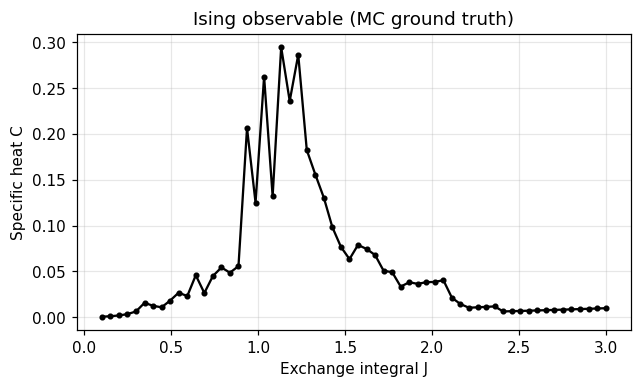

Peak near J = 1.13,  C_max = 0.295


In [60]:
# Compute MC ground truth once — reuse in every later plot
J_LO, J_HI = 0.1, 3.0
Jgrid = np.linspace(J_LO, J_HI, 60)
truth = np.array([ising_observable(float(j)) for j in Jgrid])

plt.figure(figsize=(6.5, 3.5))
plt.plot(Jgrid, truth, 'k.-')
plt.xlabel('Exchange integral J'); plt.ylabel('Specific heat C')
plt.title('Ising observable (MC ground truth)'); plt.grid(alpha=0.3); plt.show()

print(f"Peak near J = {Jgrid[np.argmax(truth)]:.2f},  C_max = {truth.max():.3f}")

In [61]:
from scipy.stats import norm

def bo_loop(strategy='ei', n_init=3, n_iter=15, seed=0):
    rng = np.random.default_rng(seed)
    bounds = (J_LO, J_HI)                                  # ✅ matches truth
    X = rng.uniform(*bounds, n_init).reshape(-1, 1)
    y = np.array([ising_observable(float(j)) for j in X.ravel()])

    Xc = np.linspace(*bounds, 300).reshape(-1, 1)
    history = []
    for t in range(n_iter):
        k = (C(1.0, (1e-2, 1e2)) * RBF(0.3, (1e-2, 1e1))
             + WhiteKernel(1e-3, (1e-6, 1e-1)))            # length-scale upped for wider range
        gp = GaussianProcessRegressor(kernel=k, normalize_y=True,
                                      n_restarts_optimizer=5, random_state=0).fit(X, y)
        mu, sd = gp.predict(Xc, return_std=True)

        if strategy == 'explore':
            acq = sd
        elif strategy == 'ei':
            y_best = y.max()
            imp = mu - y_best
            Z = imp / np.where(sd > 1e-9, sd, 1e-9)
            acq = imp * norm.cdf(Z) + sd * norm.pdf(Z)
            acq[sd < 1e-9] = 0

        x_next = Xc[np.argmax(acq)].reshape(1, -1)
        y_next = ising_observable(float(x_next[0, 0]))
        X = np.vstack([X, x_next]); y = np.append(y, y_next)
        history.append((X.copy(), y.copy(), mu, sd))
    return X, y, history

X_ex, y_ex, hist_ex = bo_loop('explore', seed=1)
X_ei, y_ei, hist_ei = bo_loop('ei',      seed=1)
print("Best found — exploration:", y_ex.max(), " | optimization (EI):", y_ei.max())

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergence

Best found — exploration: 0.262302285350881  | optimization (EI): 0.3062896182961681


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


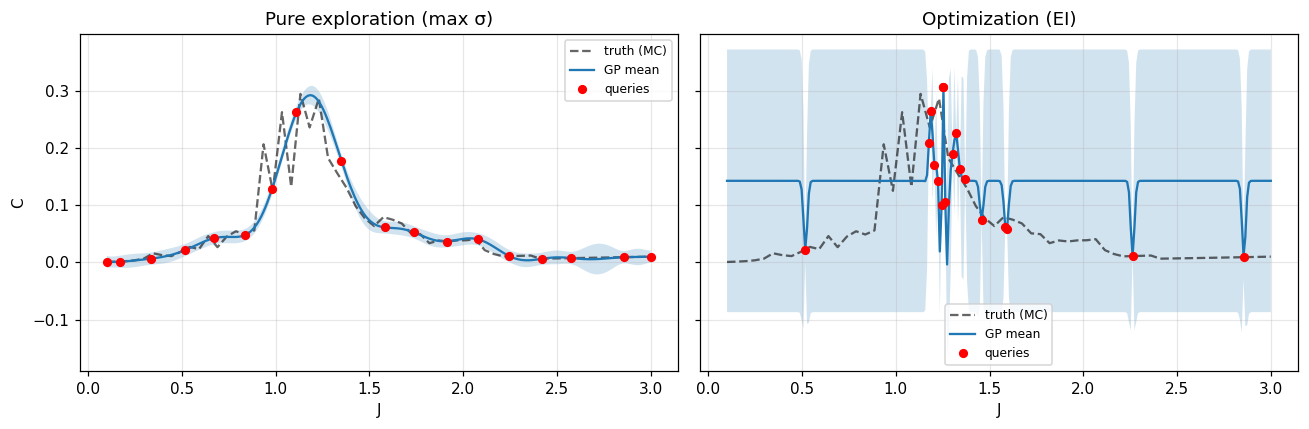

In [62]:
Xc = np.linspace(J_LO, J_HI, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (X, y, label) in zip(axes,
    [(X_ex, y_ex, 'Pure exploration (max σ)'),
     (X_ei, y_ei, 'Optimization (EI)')]):
    k = (C(1.0, (1e-2, 1e2)) * RBF(0.3, (1e-2, 1e1))
         + WhiteKernel(1e-3, (1e-6, 1e-1)))
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True,
                                  n_restarts_optimizer=5, random_state=0).fit(X, y)
    mu, sd = gp.predict(Xc, return_std=True)
    ax.plot(Jgrid, truth, 'k--', alpha=0.6, label='truth (MC)')   # ✅ reuse
    ax.plot(Xc, mu, 'C0-', label='GP mean')
    ax.fill_between(Xc.ravel(), mu - 2*sd, mu + 2*sd, alpha=0.2)
    ax.plot(X, y, 'ro', ms=5, label='queries')
    ax.set_title(label); ax.set_xlabel('J')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('C')
plt.tight_layout(); plt.show()

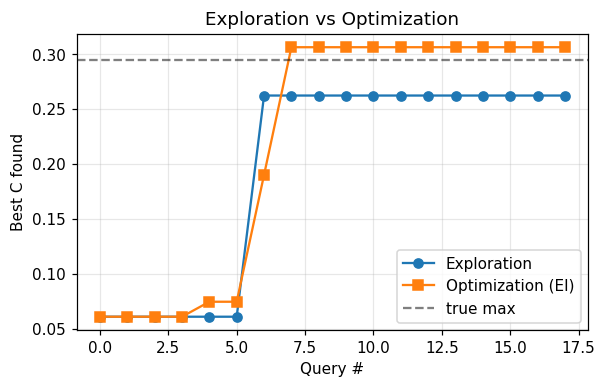

In [63]:
def best_so_far(y): return np.maximum.accumulate(y)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(best_so_far(y_ex), 'o-', label='Exploration')
ax.plot(best_so_far(y_ei), 's-', label='Optimization (EI)')
ax.axhline(truth.max(), color='k', ls='--', alpha=0.5, label='true max')
ax.set_xlabel('Query #'); ax.set_ylabel('Best C found')
ax.set_title('Exploration vs Optimization'); ax.legend(); ax.grid(alpha=0.3); plt.show()